In [1]:
!pip install ucimlrepo
import pandas as pd, numpy as np, sklearn, matplotlib
print(sklearn.__version__, pd.__version__)

1.6.1 2.2.3


In [2]:
from ucimlrepo import fetch_ucirepo

repo = fetch_ucirepo(id=165)
X = repo.data.features.copy()
y = repo.data.targets.copy()

print(X.shape)
print(X.columns.tolist())
X.head()


(1030, 8)
['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [3]:
import numpy as np
import pandas as pd

X.columns = ["cement", "slag", "fly_ash", "water", "superplasticizer",
             "coarse_agg", "fine_agg", "age"]

y = pd.Series(np.asarray(y).ravel(), name="strength")

print(y.describe().round(1))
X.describe().round(1)

count    1030.0
mean       35.8
std        16.7
min         2.3
25%        23.7
50%        34.4
75%        46.1
max        82.6
Name: strength, dtype: float64


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age
count,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0
mean,281.2,73.9,54.2,181.6,6.2,972.9,773.6,45.7
std,104.5,86.3,64.0,21.4,6.0,77.8,80.2,63.2
min,102.0,0.0,0.0,121.8,0.0,801.0,594.0,1.0
25%,192.4,0.0,0.0,164.9,0.0,932.0,731.0,7.0
50%,272.9,22.0,0.0,185.0,6.4,968.0,779.5,28.0
75%,350.0,143.0,118.3,192.0,10.2,1029.4,824.0,56.0
max,540.0,359.4,200.1,247.0,32.2,1145.0,992.6,365.0


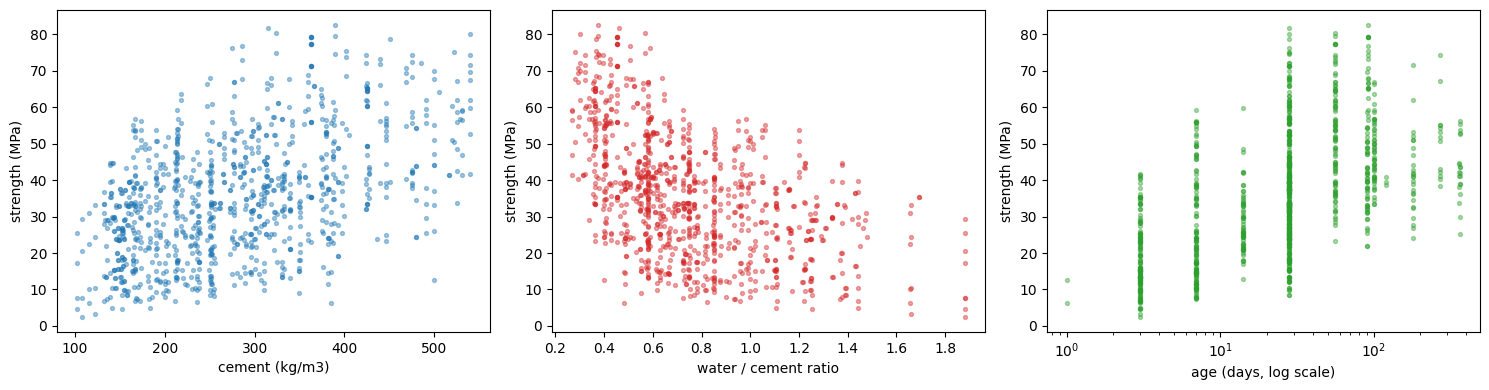

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].scatter(X["cement"], y, s=8, alpha=0.4)
ax[0].set(xlabel="cement (kg/m3)", ylabel="strength (MPa)")

ax[1].scatter(X["water"] / X["cement"], y, s=8, alpha=0.4, color="tab:red")
ax[1].set(xlabel="water / cement ratio", ylabel="strength (MPa)")

ax[2].scatter(X["age"], y, s=8, alpha=0.4, color="tab:green")
ax[2].set(xlabel="age (days, log scale)", ylabel="strength (MPa)", xscale="log")

plt.tight_layout()
plt.show()

count    1030.00
mean        0.47
std         0.13
min         0.24
25%         0.38
50%         0.47
75%         0.56
max         0.90
Name: water_binder, dtype: float64


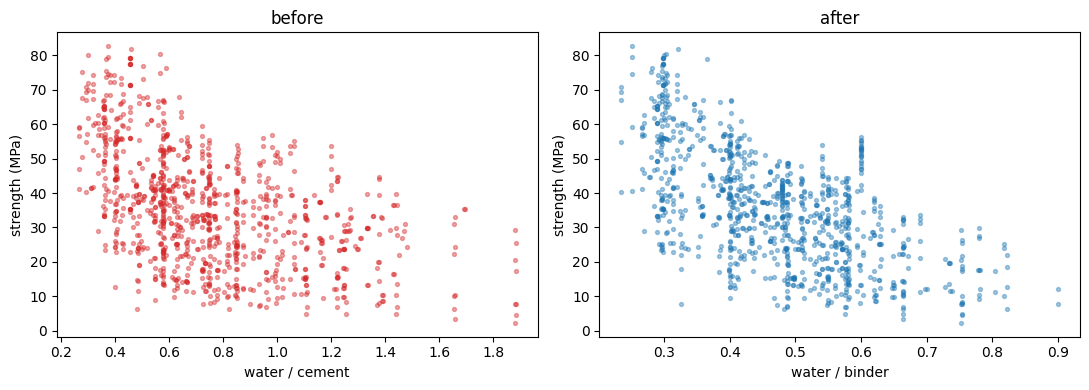

In [5]:
binder = X["cement"] + X["slag"] + X["fly_ash"]
X["water_binder"] = X["water"] / binder
X["log_age"] = np.log(X["age"])

print(X["water_binder"].describe().round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(X["water"] / X["cement"], y, s=8, alpha=0.4, color="tab:red")
ax[0].set(xlabel="water / cement", ylabel="strength (MPa)", title="before")
ax[1].scatter(X["water_binder"], y, s=8, alpha=0.4, color="tab:blue")
ax[1].set(xlabel="water / binder", ylabel="strength (MPa)", title="after")
plt.tight_layout()
plt.show()

In [2]:
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

repo = fetch_ucirepo(id=165)
X = repo.data.features.copy()
y = pd.Series(np.asarray(repo.data.targets).ravel(), name="strength")

X.columns = ["cement", "slag", "fly_ash", "water", "superplasticizer",
             "coarse_agg", "fine_agg", "age"]

binder = X["cement"] + X["slag"] + X["fly_ash"]
X["water_binder"] = X["water"] / binder
X["log_age"] = np.log(X["age"])

print(X.shape, "| w/b max:", round(X["water_binder"].max(), 2))

(1030, 10) | w/b max: 0.9


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

raw_cols = ["cement", "slag", "fly_ash", "water", "superplasticizer",
            "coarse_agg", "fine_agg", "age"]
all_cols = raw_cols + ["water_binder", "log_age"]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train {len(Xtr)}, test {len(Xte)}")

for label, cols in [("raw features", raw_cols), ("+ w/b, log age", all_cols)]:
    model = LinearRegression().fit(Xtr[cols], ytr)
    pred = model.predict(Xte[cols])
    rmse = mean_squared_error(yte, pred) ** 0.5
    print(f"{label:>16}:  RMSE {rmse:5.2f} MPa   R2 {r2_score(yte, pred):.3f}")

train 824, test 206
    raw features:  RMSE  9.80 MPa   R2 0.628
  + w/b, log age:  RMSE  6.57 MPa   R2 0.832


In [4]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

results = [
    ("Linear (raw)", 9.80, 0.628),
    ("Linear (+ w/b, log age)", 6.57, 0.832),
]

models = {
    "Random forest": RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1),
    "Gradient boosting": GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                                   max_depth=3, random_state=42),
}

for name, model in models.items():
    model.fit(Xtr[all_cols], ytr)
    pred = model.predict(Xte[all_cols])
    rmse = mean_squared_error(yte, pred) ** 0.5
    r2 = r2_score(yte, pred)
    results.append((name, round(rmse, 2), round(r2, 3)))
    print(f"{name:>20}:  RMSE {rmse:5.2f} MPa   R2 {r2:.3f}")

rf = models["Random forest"]
table = pd.DataFrame(results, columns=["model", "rmse_mpa", "r2"])

       Random forest:  RMSE  4.69 MPa   R2 0.915
   Gradient boosting:  RMSE  4.40 MPa   R2 0.925


In [5]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = -cross_val_score(model, Xtr[all_cols], ytr, cv=cv,
                              scoring="neg_root_mean_squared_error")
    print(f"{name:>20}:  CV RMSE {scores.mean():.2f} +/- {scores.std():.2f} MPa")

       Random forest:  CV RMSE 5.31 +/- 0.42 MPa
   Gradient boosting:  CV RMSE 4.72 +/- 0.38 MPa


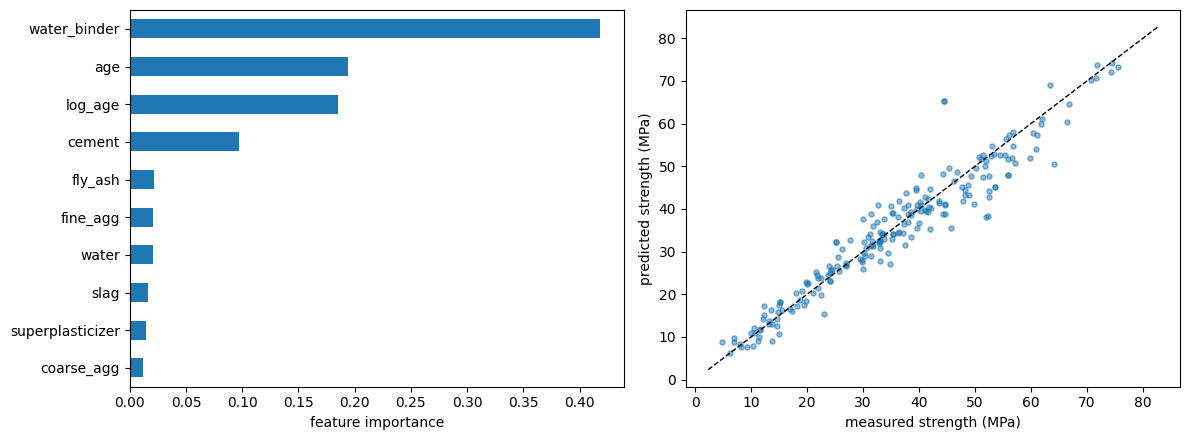

water_binder        0.419
age                 0.194
log_age             0.186
cement              0.097
fly_ash             0.021
fine_agg            0.021
water               0.021
slag                0.016
superplasticizer    0.014
coarse_agg          0.011


In [6]:
best = models["Gradient boosting"]
pred = best.predict(Xte[all_cols])

importance = pd.Series(best.feature_importances_, index=all_cols).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

importance.plot.barh(ax=ax[0])
ax[0].set(xlabel="feature importance")

ax[1].scatter(yte, pred, s=14, alpha=0.5)
lims = [y.min(), y.max()]
ax[1].plot(lims, lims, "k--", lw=1)
ax[1].set(xlabel="measured strength (MPa)", ylabel="predicted strength (MPa)")

plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False).round(3).to_string())

In [7]:
no_raw_age = [c for c in all_cols if c != "age"]
no_log_age = [c for c in all_cols if c != "log_age"]

for label, cols in [("both age terms", all_cols),
                    ("log_age only", no_raw_age),
                    ("raw age only", no_log_age)]:
    m = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                  max_depth=3, random_state=42)
    s = -cross_val_score(m, Xtr[cols], ytr, cv=cv,
                         scoring="neg_root_mean_squared_error")
    print(f"{label:>16}:  CV RMSE {s.mean():.2f} +/- {s.std():.2f} MPa")

worst = (pred - yte).abs().idxmax()
print("\nWorst prediction:")
print(X.loc[worst].round(2).to_string())
print(f"measured {y.loc[worst]:.1f} MPa, predicted {pred[list(yte.index).index(worst)]:.1f} MPa")

  both age terms:  CV RMSE 4.72 +/- 0.38 MPa
    log_age only:  CV RMSE 4.71 +/- 0.40 MPa
    raw age only:  CV RMSE 4.73 +/- 0.39 MPa

Worst prediction:
cement               313.00
slag                 145.00
fly_ash                0.00
water                127.00
superplasticizer       8.00
coarse_agg          1000.00
fine_agg             822.00
age                   28.00
water_binder           0.28
log_age                3.33
measured 44.5 MPa, predicted 65.3 MPa


In [8]:
final_cols = [c for c in all_cols if c != "age"]
final = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                  max_depth=3, random_state=42).fit(Xtr[final_cols], ytr)

table.to_csv("results.csv", index=False)
print(table.to_string(index=False))

                  model  rmse_mpa    r2
           Linear (raw)      9.80 0.628
Linear (+ w/b, log age)      6.57 0.832
          Random forest      4.69 0.915
      Gradient boosting      4.40 0.925


saved 3 figures + results.csv


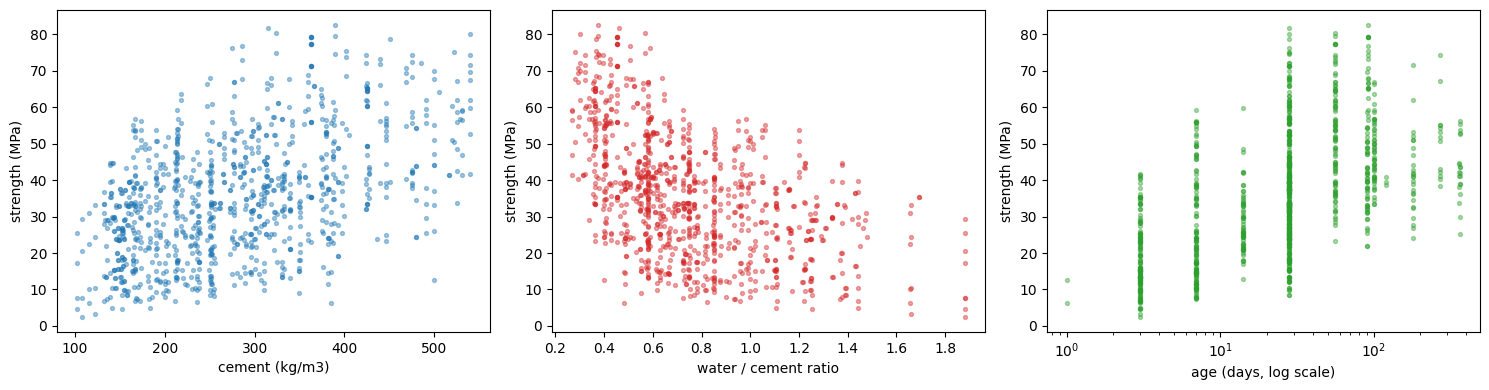

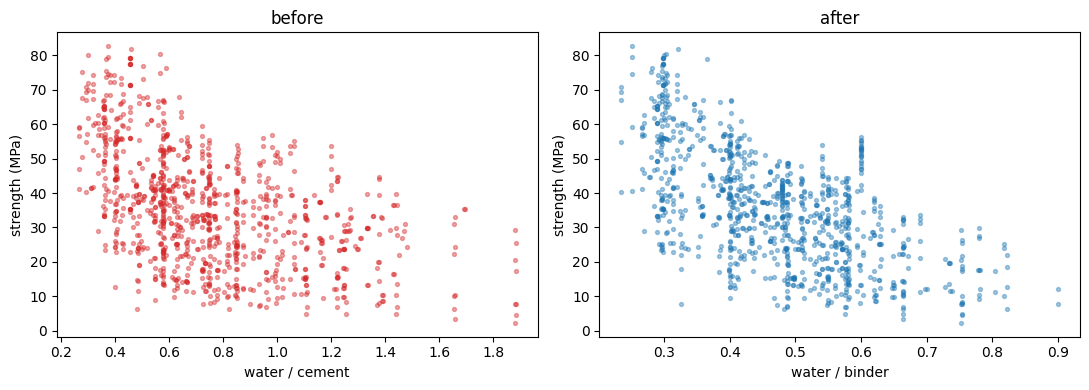

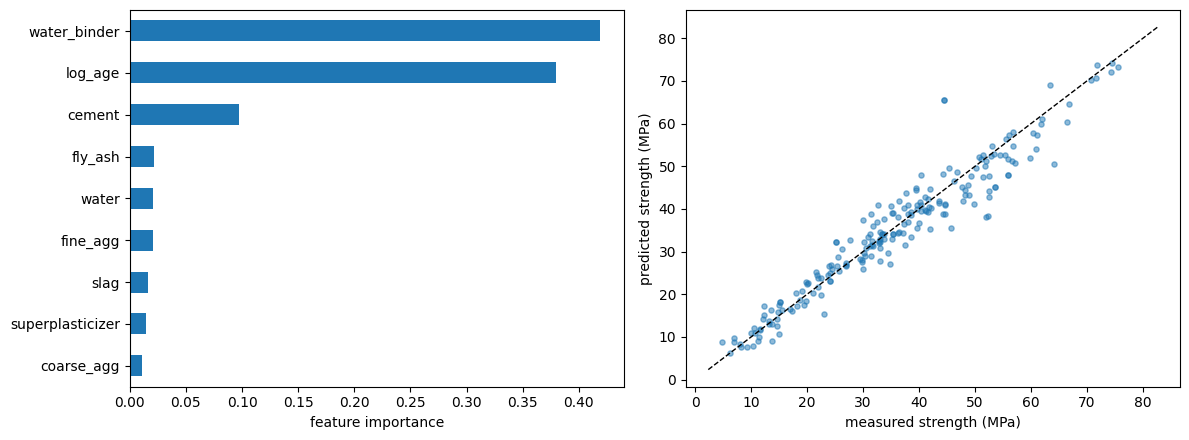

In [9]:
final_cols = [c for c in all_cols if c != "age"]
final = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                  max_depth=3, random_state=42).fit(Xtr[final_cols], ytr)
pred = final.predict(Xte[final_cols])

# fig 1: what the raw data looks like
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(X["cement"], y, s=8, alpha=0.4)
ax[0].set(xlabel="cement (kg/m3)", ylabel="strength (MPa)")
ax[1].scatter(X["water"] / X["cement"], y, s=8, alpha=0.4, color="tab:red")
ax[1].set(xlabel="water / cement ratio", ylabel="strength (MPa)")
ax[2].scatter(X["age"], y, s=8, alpha=0.4, color="tab:green")
ax[2].set(xlabel="age (days, log scale)", ylabel="strength (MPa)", xscale="log")
fig.tight_layout()
fig.savefig("fig1_exploration.png", dpi=150)

# fig 2: why the binder term is the right denominator
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(X["water"] / X["cement"], y, s=8, alpha=0.4, color="tab:red")
ax[0].set(xlabel="water / cement", ylabel="strength (MPa)", title="before")
ax[1].scatter(X["water_binder"], y, s=8, alpha=0.4, color="tab:blue")
ax[1].set(xlabel="water / binder", ylabel="strength (MPa)", title="after")
fig.tight_layout()
fig.savefig("fig2_water_binder.png", dpi=150)

# fig 3: what the model used, and how well it did
importance = pd.Series(final.feature_importances_, index=final_cols).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
importance.plot.barh(ax=ax[0])
ax[0].set(xlabel="feature importance")
ax[1].scatter(yte, pred, s=14, alpha=0.5)
ax[1].plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=1)
ax[1].set(xlabel="measured strength (MPa)", ylabel="predicted strength (MPa)")
fig.tight_layout()
fig.savefig("fig3_results.png", dpi=150)

table.to_csv("results.csv", index=False)
print("saved 3 figures + results.csv")